In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from src import baseClasses, systemClasses, sensorClasses, muxClasses, observableClasses
import datetime
import numpy as np
from tqdm import tqdm
from scipy.optimize import curve_fit
from scipy import stats
import pickle
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("style.mplstyle")

In [2]:
def combine_profiles(system):
    # Calculate mean temperature at each (X, Y, Z) coordinate from all profiles

    all_temps_centered = []
    for timestamp, profile_df in system.profiles.items():
        # Calculate the mean temperature for this specific profile
        if "temp" not in profile_df.columns:
            continue
        profile_df = profile_df.loc[(profile_df["temp"]<88)]
        profile_df = profile_df.loc[(profile_df["temp"]>87)]
        profile_df = profile_df.dropna(axis=0)
        profile_mean = profile_df['temp'].mean()

        # Create a copy of the profile and center it by subtracting the profile mean
        profile_centered = profile_df.copy()
        profile_centered['temp'] = (profile_df['temp']) * 1000
        profile_centered['timestamp'] = timestamp
        profile_centered['profile_mean'] = profile_mean  # Keep track of original profile mean

        all_temps_centered.append(profile_centered)
    # Combine all centered profiles into one DataFrame
    combined_profiles_centered = pd.concat(all_temps_centered, ignore_index=True)
    return combined_profiles_centered

In [3]:
def gaussian(x, mu, sigma, A):
    # Gaussian definitio with amplitude
    return A * np.exp(-0.5 * ((x - mu) / sigma)**2)

def fit_gaussian_per_coord(combined_profiles):
    # Fit Gaussian to each coordinate's centered temperature distribution
    # Extract mean and sigma to study profile shape stability

    # Get unique coordinates
    unique_coords = combined_profiles[['X', 'Y', 'Z']].drop_duplicates()

    # Store results
    gaussian_fits = []

    for _, coord in unique_coords.iterrows():
        x, y, z = coord['X'], coord['Y'], coord['Z']

        # Get centered temperatures for this coordinate
        coord_temps = combined_profiles[
            (combined_profiles['X'] == x) &
            (combined_profiles['Y'] == y) &
            (combined_profiles['Z'] == z)
        ]['temp'].values

        coord_profile_mean = combined_profiles[
            (combined_profiles['X'] == x) &
            (combined_profiles['Y'] == y) &
            (combined_profiles['Z'] == z)
        ]['profile_mean'].mean()

        if coord_profile_mean > 89:
            continue

        if len(coord_temps) < 10:  # Skip if too few points
            print(f"Skipped for ({x},{y},{z}): Only {len(coord_temps)} points!")
            continue

        # Create histogram to fit Gaussian
        hist, bin_edges = np.histogram(coord_temps, bins=30, density=True)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

        # Initial guess for Gaussian parameters
        mu_guess = np.mean(coord_temps)
        sigma_guess = np.std(coord_temps)
        A_guess = np.max(hist)

        try:
            # Fit Gaussian
            popt, pcov = curve_fit(gaussian, bin_centers, hist,
                                p0=[mu_guess, sigma_guess, A_guess],
                                maxfev=1000)

            mu_fit, sigma_fit, A_fit = popt

            mu_err = np.sqrt(pcov[0, 0])  # Error on mean
            sigma_err = np.sqrt(pcov[1, 1])  # Error on sigma
            A_err = np.sqrt(pcov[2, 2])  # Error on amplitude

            # Calculate R-squared
            y_pred = gaussian(bin_centers, *popt)
            r_squared = 1 - np.sum((hist - y_pred)**2) / np.sum((hist - np.mean(hist))**2)

            # if r_squared<0.9:
            #     print(f"Skipped for ({x},{y},{z}): R-squared = {r_squared:.2f}")
            #     continue

            gaussian_fits.append({
                'X': x, 'Y': y, 'Z': z,
                'mu': mu_fit,
                'mu_err': mu_err,
                'sigma': sigma_fit,
                'sigma_err': sigma_err,
                'A': A_fit,
                'A_err': A_err,
                'r_squared': r_squared,
                'n_points': len(coord_temps)
            })

        except:
            print(f"Fit failed for ({x},{y},{z})")
            continue

    # Convert to DataFrame
    gaussian_results = pd.DataFrame(gaussian_fits)
    return gaussian_results


# First Normal Operation Period

Goal is to evaluate the homogeneity of the temperature map during the first normal operation period

In [38]:
dataset = baseClasses.Data()

(19843.0, 20060.0)

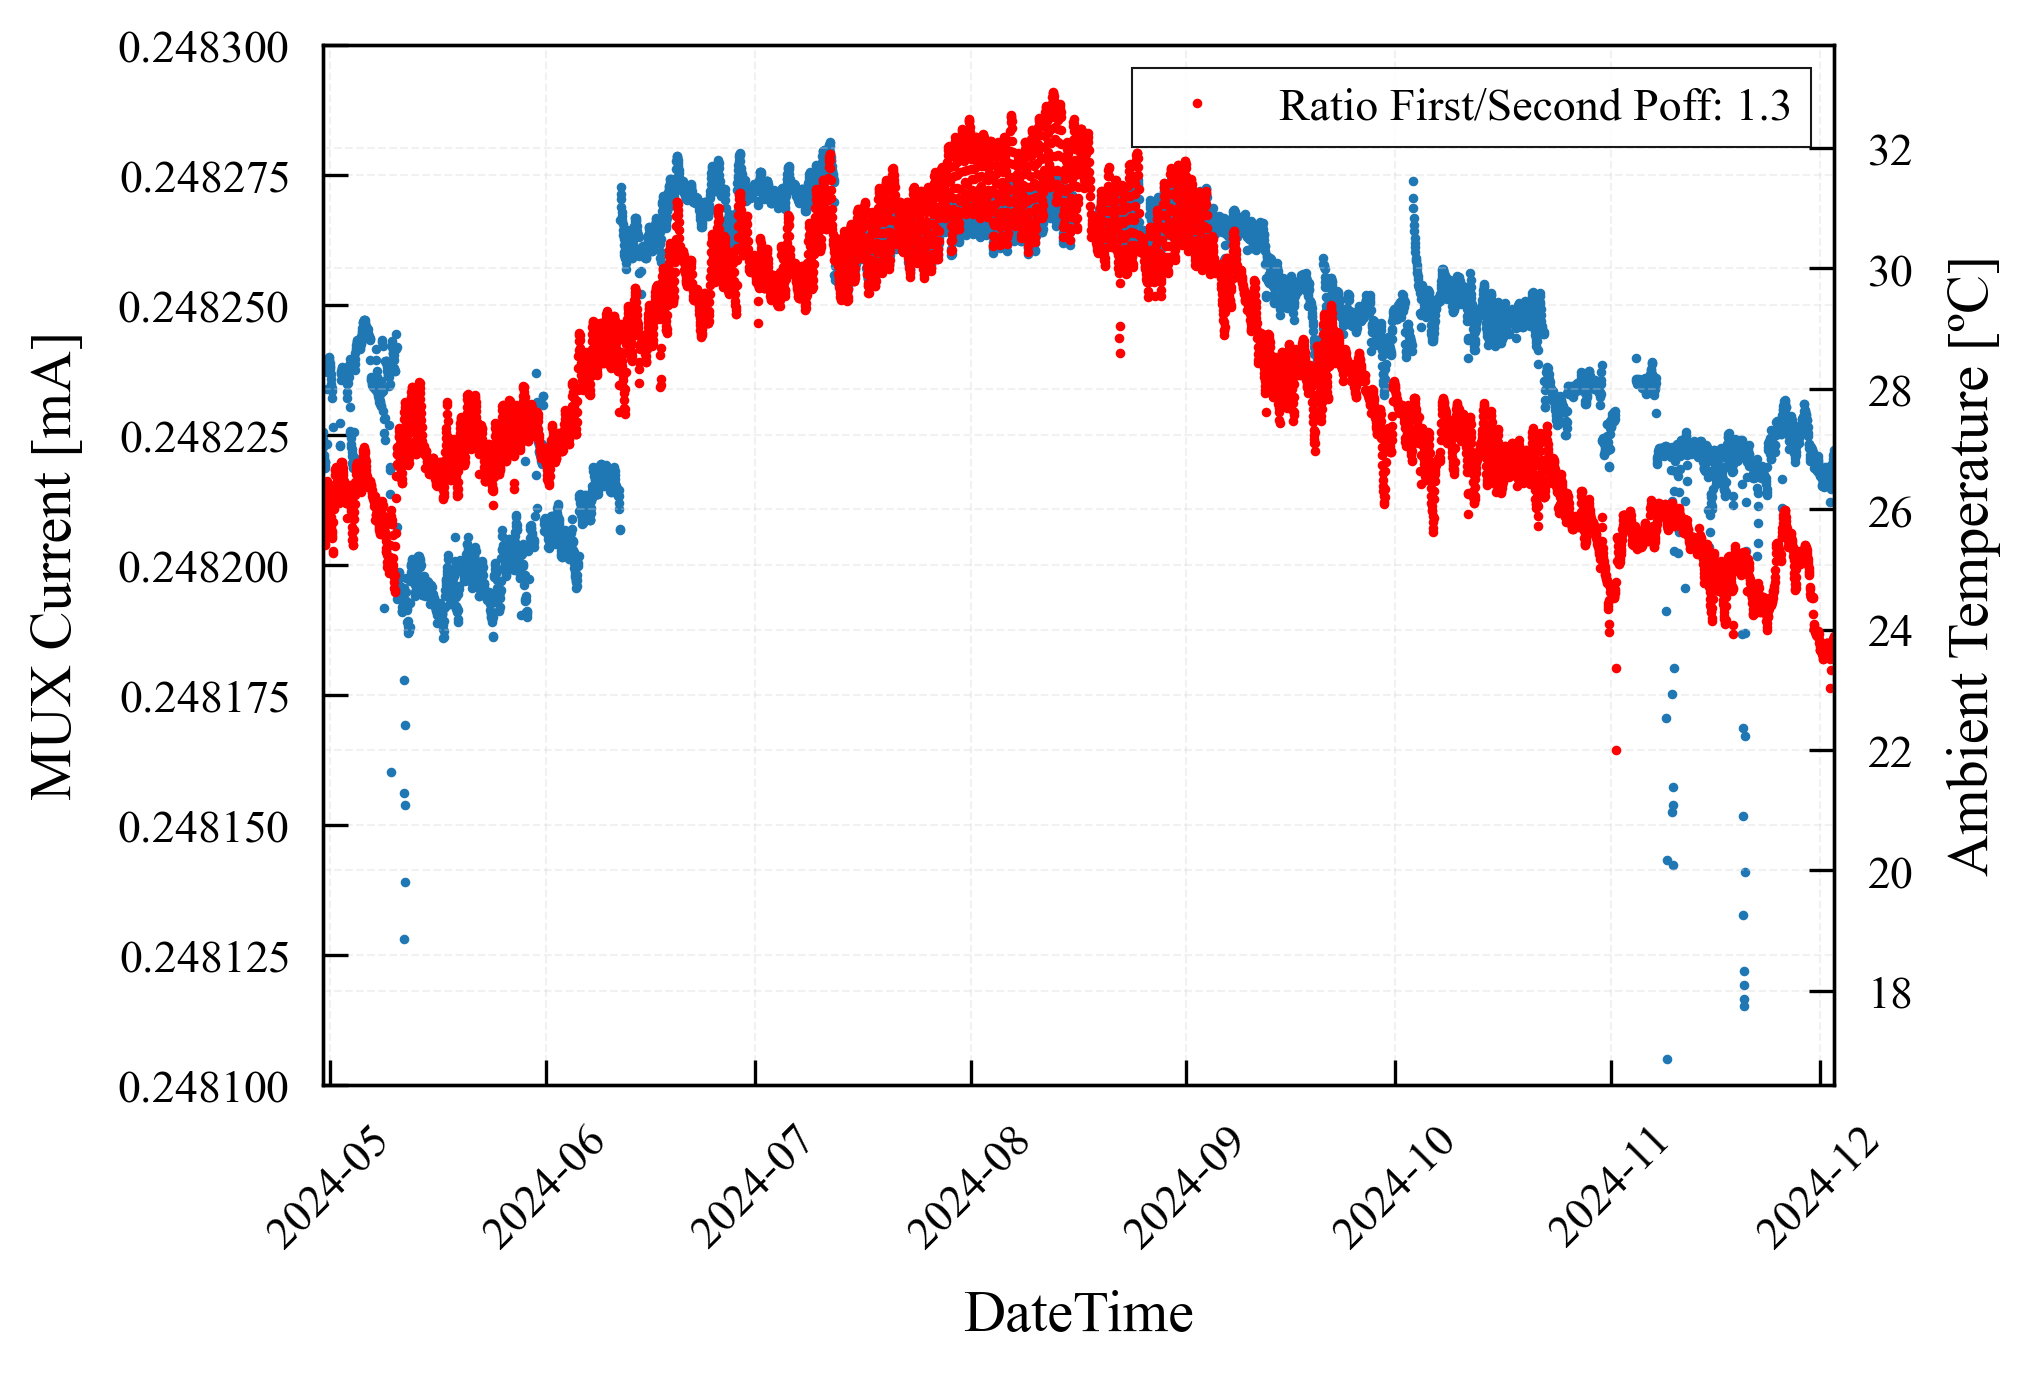

In [39]:
mux4 = muxClasses.MUX(dataset, boardNumber=4)
ambientT = sensorClasses.Sensor(dataset, id=1037)

meanT_first_period = ambientT.data.loc[(ambientT.data.index > datetime.datetime(2024, 6, 15)) & (ambientT.data.index < datetime.datetime(2024, 8, 1))].mean()
meanT_second_poff = ambientT.data.loc[(ambientT.data.index > datetime.datetime(2024, 12, 1)) & (ambientT.data.index < datetime.datetime(2024, 12, 5))].mean()
ratioT = meanT_first_period/meanT_second_poff
fig, axes = plt.subplots(1,1)
axes.plot(mux4.data.resample("1H").mean().index.values, 1/mux4.data.resample("1H").mean().values, marker="o", markersize=1.5, linestyle="None")
axes.tick_params(axis='x', rotation=45)
axes.set_xlabel("DateTime")
axes.set_ylabel("MUX Current [mA]")

axes2 = axes.twinx()
axes2.plot(ambientT.data.resample("1H").mean().index.values, ambientT.data.resample("1H").mean().values, color="red", marker="o", markersize=1.5, linestyle="None", label=fr"Ratio First/Second Poff: {ratioT:.1f}")
axes2.set_ylabel("Ambient Temperature [ºC]")
axes.set_ylim(0.2481, 0.2483)
axes2.legend()
axes.set_xlim(datetime.datetime(2024, 4, 30), datetime.datetime(2024, 12, 3))



In [40]:
mask = (
    ((dataset.data.index > datetime.datetime(2024, 6, 15)) & (dataset.data.index < datetime.datetime(2024, 8, 1)))
)

dataset.data = dataset.data.loc[mask]
dataset.err = dataset.err.loc[mask]

In [41]:
tgrad = systemClasses.System(dataset, "TGRAD")
hawai = systemClasses.System(dataset, "HAWAI")
prm = systemClasses.System(dataset, "PRM")
inlet = systemClasses.System(dataset, sensor_names=["1-I", "3-I", "4-I"])
upstream = systemClasses.System(dataset, sensor_names=["2-M", "4-M"])
middle = systemClasses.System(dataset, sensor_names=["1-M", "3-M"])
downstream = systemClasses.System(dataset, sensor_names=["1-U", "2-U", "3-U", "4-U"])
pipes = systemClasses.System(dataset, "PIPE")
pumps = systemClasses.System(dataset, "PP")
tgrad.calibrate("SECOND_POFF_OCTOBER")
hawai.calibrate("SECOND_POFF_EMPTY")
prm.calibrate("SECOND_POFF_OCTOBER")
pipes.calibrate("SECOND_POFF_OCTOBER")
pumps.calibrate("SECOND_POFF_OCTOBER")
inlet.calibrate("SECOND_POFF_OCTOBER")
upstream.calibrate("SECOND_POFF_OCTOBER")
middle.calibrate("SECOND_POFF_OCTOBER")
downstream.calibrate("SECOND_POFF_OCTOBER")

Initializing TGRAD Sensors:   0%|          | 0/48 [00:00<?, ?sensor/s]

Initializing Custom Sensors: 100%|██████████| 2/2 [00:00<00:00, 11.91sensor/s]


ERROR: Channel (TE0120) not found


Initializing PIPE Sensors: 100%|██████████| 12/12 [00:01<00:00,  9.52sensor/s]


ERROR: Channel (TE0120) not found


Equalizing TGRAD Sensors: 100%|██████████| 48/48 [00:04<00:00,  9.79sensor/s]
Calibrating TGRAD Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 48/48 [00:00<00:00, 94.12sensor/s]
Equalizing HAWAI Sensors: 100%|██████████| 24/24 [00:02<00:00, 10.93sensor/s]
Calibrating HAWAI Sensors - Calibration Name: SECOND_POFF_EMPTY: 100%|██████████| 24/24 [00:00<00:00, 75.30sensor/s]
Equalizing PRM Sensors: 100%|██████████| 6/6 [00:00<00:00,  8.58sensor/s]
Calibrating PRM Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 6/6 [00:00<00:00, 86.43sensor/s]
Equalizing PIPE Sensors: 100%|██████████| 12/12 [00:01<00:00,  7.58sensor/s]


ERROR: Channel (TE0120) not found


Calibrating PIPE Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 12/12 [00:00<00:00, 87.55sensor/s]
Equalizing PP Sensors: 100%|██████████| 2/2 [00:00<00:00,  8.90sensor/s]
Calibrating PP Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 2/2 [00:00<00:00, 82.77sensor/s]
Equalizing Custom Sensors: 100%|██████████| 3/3 [00:00<00:00,  8.84sensor/s]
Calibrating Custom Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 3/3 [00:00<00:00, 83.10sensor/s]
Equalizing Custom Sensors: 100%|██████████| 2/2 [00:00<00:00, 10.56sensor/s]


ERROR: Channel (TE0120) not found


Calibrating Custom Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 2/2 [00:00<00:00, 80.64sensor/s]
Equalizing Custom Sensors: 100%|██████████| 2/2 [00:00<00:00,  8.08sensor/s]
Calibrating Custom Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 2/2 [00:00<00:00, 58.32sensor/s]
Equalizing Custom Sensors: 100%|██████████| 4/4 [00:00<00:00, 10.00sensor/s]
Calibrating Custom Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 4/4 [00:00<00:00, 101.59sensor/s]


In [42]:
tgrad.makeProfiles(deltat=45)
hawai.makeProfiles(deltat=45)
prm.makeProfiles(deltat=45)
pipes.makeProfiles(deltat=45)
pumps.makeProfiles(deltat=45)
inlet.makeProfiles(deltat=45)
upstream.makeProfiles(deltat=45)
middle.makeProfiles(deltat=45)
downstream.makeProfiles(deltat=45)


Calculating TGRAD temperature profiles every 45 minutes: : 1504step [00:26, 56.08step/s]                      
Calculating HAWAI temperature profiles every 45 minutes: : 1504step [00:13, 112.80step/s]                      
Calculating PRM temperature profiles every 45 minutes: : 1504step [00:03, 440.18step/s]                      
Calculating PIPE temperature profiles every 45 minutes: : 1504step [00:06, 225.64step/s]                      
Calculating PP temperature profiles every 45 minutes: : 1504step [00:01, 1180.25step/s]                      
Calculating Custom temperature profiles every 45 minutes: : 1504step [00:01, 799.10step/s]                      
Calculating Custom temperature profiles every 45 minutes: : 1504step [00:01, 862.25step/s]                       
Calculating Custom temperature profiles every 45 minutes: : 1504step [00:01, 933.09step/s]                       
Calculating Custom temperature profiles every 45 minutes: : 1504step [00:02, 625.28step/s]               

In [43]:
tgrad_combined_first = combine_profiles(tgrad)
hawai_combined_first = combine_profiles(hawai)
prm_combined_first = combine_profiles(prm)
pipes_combined_first = combine_profiles(pipes)
pumps_combined_first = combine_profiles(pumps)
inlet_combined_first = combine_profiles(inlet)
upstream_combined_first = combine_profiles(upstream)
middle_combined_first = combine_profiles(middle)
downstream_combined_first = combine_profiles(downstream)

tgrad_gaussian_first = fit_gaussian_per_coord(tgrad_combined_first)
hawai_gaussian_first = fit_gaussian_per_coord(hawai_combined_first)
prm_gaussian_first = fit_gaussian_per_coord(prm_combined_first)
pipes_gaussian_first = fit_gaussian_per_coord(pipes_combined_first)
pumps_gaussian_first = fit_gaussian_per_coord(pumps_combined_first)
inlet_gaussian_first = fit_gaussian_per_coord(inlet_combined_first)
upstream_gaussian_first = fit_gaussian_per_coord(upstream_combined_first)
middle_gaussian_first = fit_gaussian_per_coord(middle_combined_first)
downstream_gaussian_first = fit_gaussian_per_coord(downstream_combined_first)

Skipped for (1452.0,179.0,5270.0): Only 6 points!


In [44]:
corr_factor = (ambientT.data - 25)*(3.85/500)

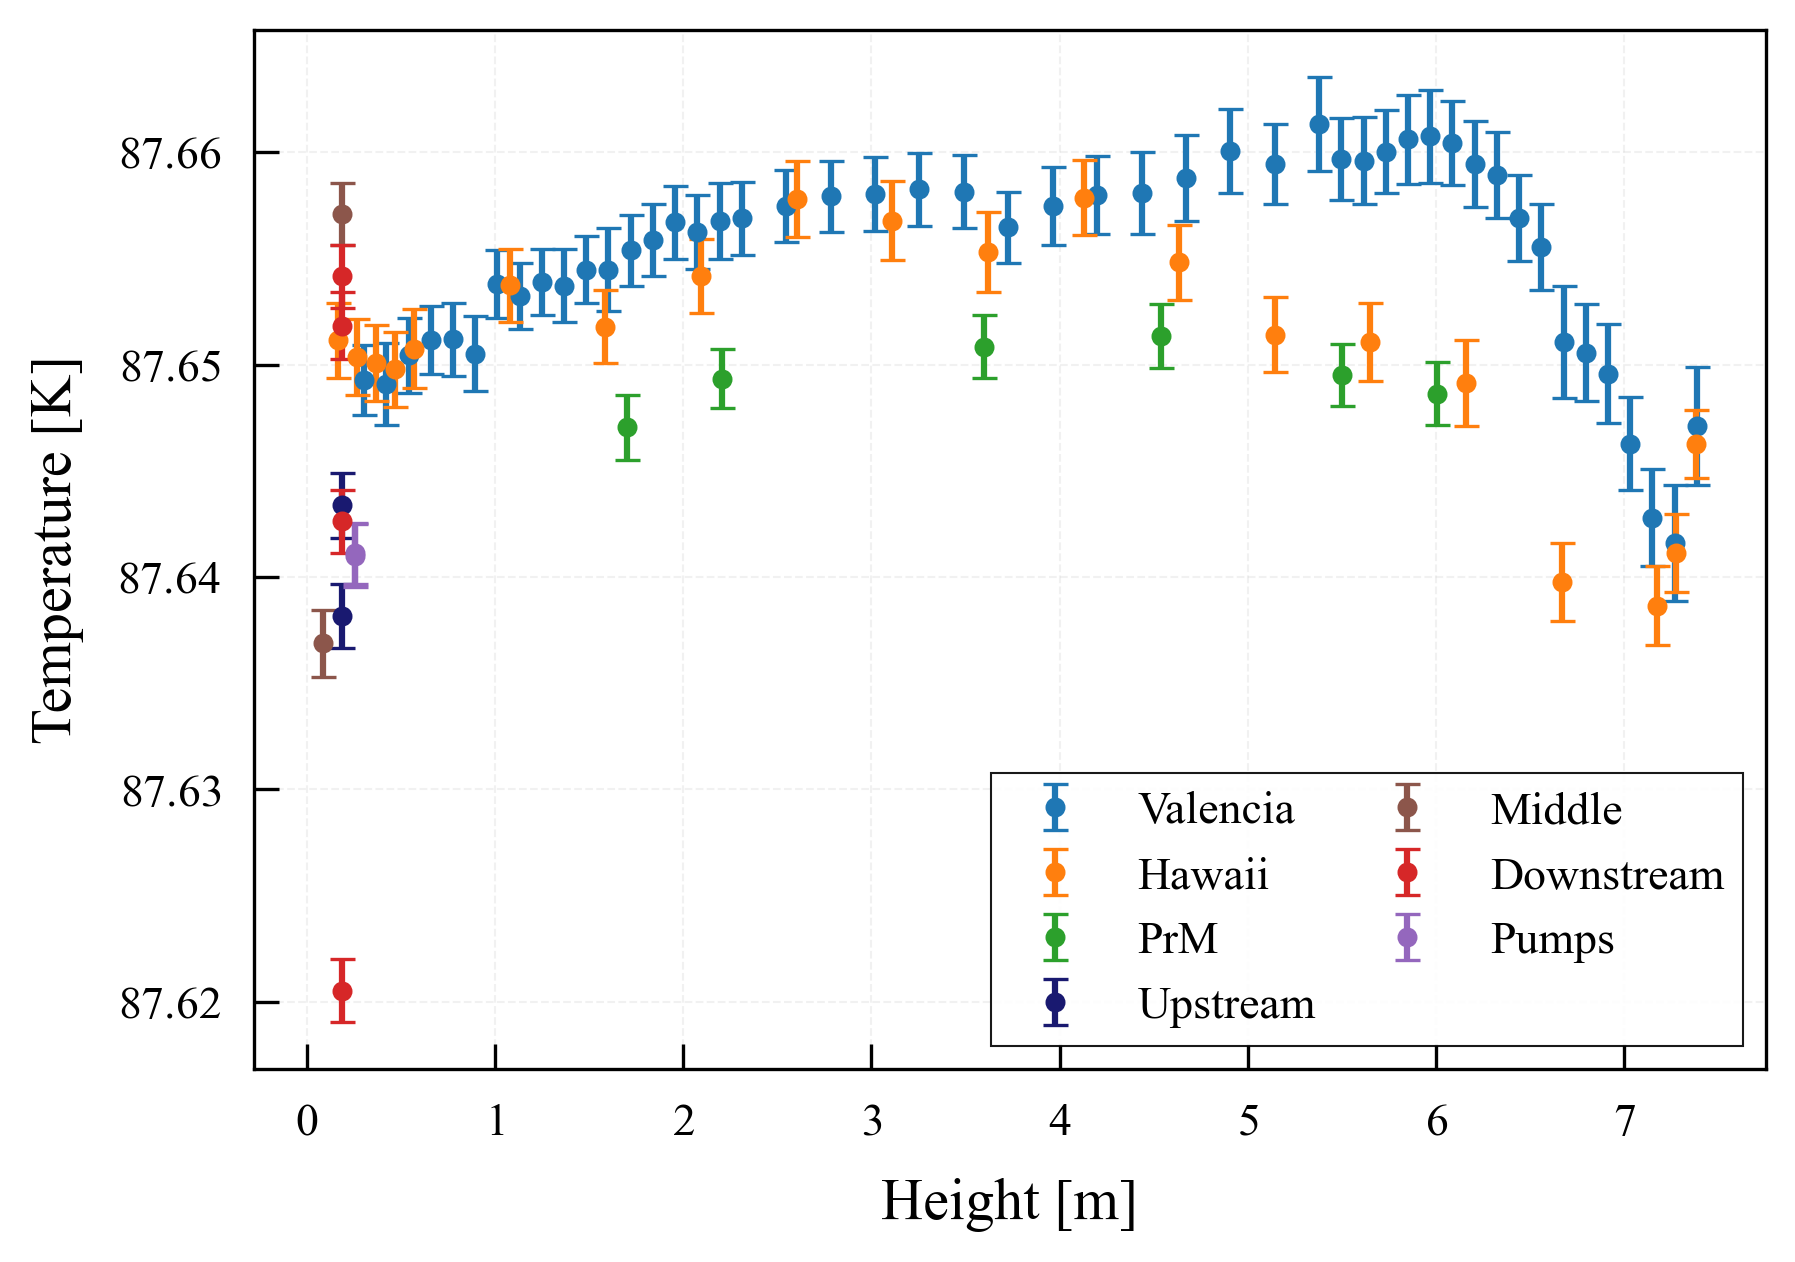

In [45]:
fig, axes = plt.subplots(1,1)
axes.errorbar(1e-3*tgrad_gaussian_first["Y"].values, 1e-3*tgrad_gaussian_first["mu"].values, yerr=1e-3*tgrad_gaussian_first["sigma"].values, fmt="o", label="Valencia", color="tab:blue")
axes.errorbar(1e-3*hawai_gaussian_first["Y"].values, 1e-3*hawai_gaussian_first["mu"].values, yerr=1e-3*hawai_gaussian_first["sigma"].values, fmt="o", label="Hawaii", color="tab:orange")
axes.errorbar(1e-3*prm_gaussian_first["Y"].values, 1e-3*prm_gaussian_first["mu"].values, yerr=1e-3*prm_gaussian_first["sigma"].values, fmt="o", label="PrM", color="tab:green")
# axes.errorbar(1e-3*pipes_gaussian_first["Y"].values, 1e-3*pipes_gaussian_first["mu"].values + corr_factor.mean(), yerr=1e-3*pipes_gaussian_first["sigma"].values, fmt="o", label="Pipes")
# axes.errorbar(1e-3*inlet_gaussian_first["Y"].values, 1e-3*inlet_gaussian_first["mu"].values + corr_factor.mean(), yerr=1e-3*inlet_gaussian_first["sigma"].values, fmt="o", label="Inlet")
axes.errorbar(1e-3*upstream_gaussian_first["Y"].values, 1e-3*upstream_gaussian_first["mu"].values, yerr=1e-3*upstream_gaussian_first["sigma"].values, fmt="o", label="Upstream", color="midnightblue")
axes.errorbar(1e-3*middle_gaussian_first["Y"].values, 1e-3*middle_gaussian_first["mu"].values, yerr=1e-3*middle_gaussian_first["sigma"].values, fmt="o", label="Middle", color="tab:brown")
axes.errorbar(1e-3*downstream_gaussian_first["Y"].values, 1e-3*downstream_gaussian_first["mu"].values, yerr=1e-3*downstream_gaussian_first["sigma"].values, fmt="o", label="Downstream", color="tab:red")
axes.errorbar(1e-3*pumps_gaussian_first["Y"].values, 1e-3*pumps_gaussian_first["mu"].values, yerr=1e-3*pumps_gaussian_first["sigma"].values, fmt="o", label="Pumps", color="tab:purple")
axes.set_xlabel("Height [m]")
axes.set_ylabel("Temperature [K]")
axes.legend(ncol=2)
fig.savefig("/Users/jcapo/cernbox/DUNE-IFIC/Publications/NP04_TMS/TMAPS/homogeneity_first_nocorr.png")

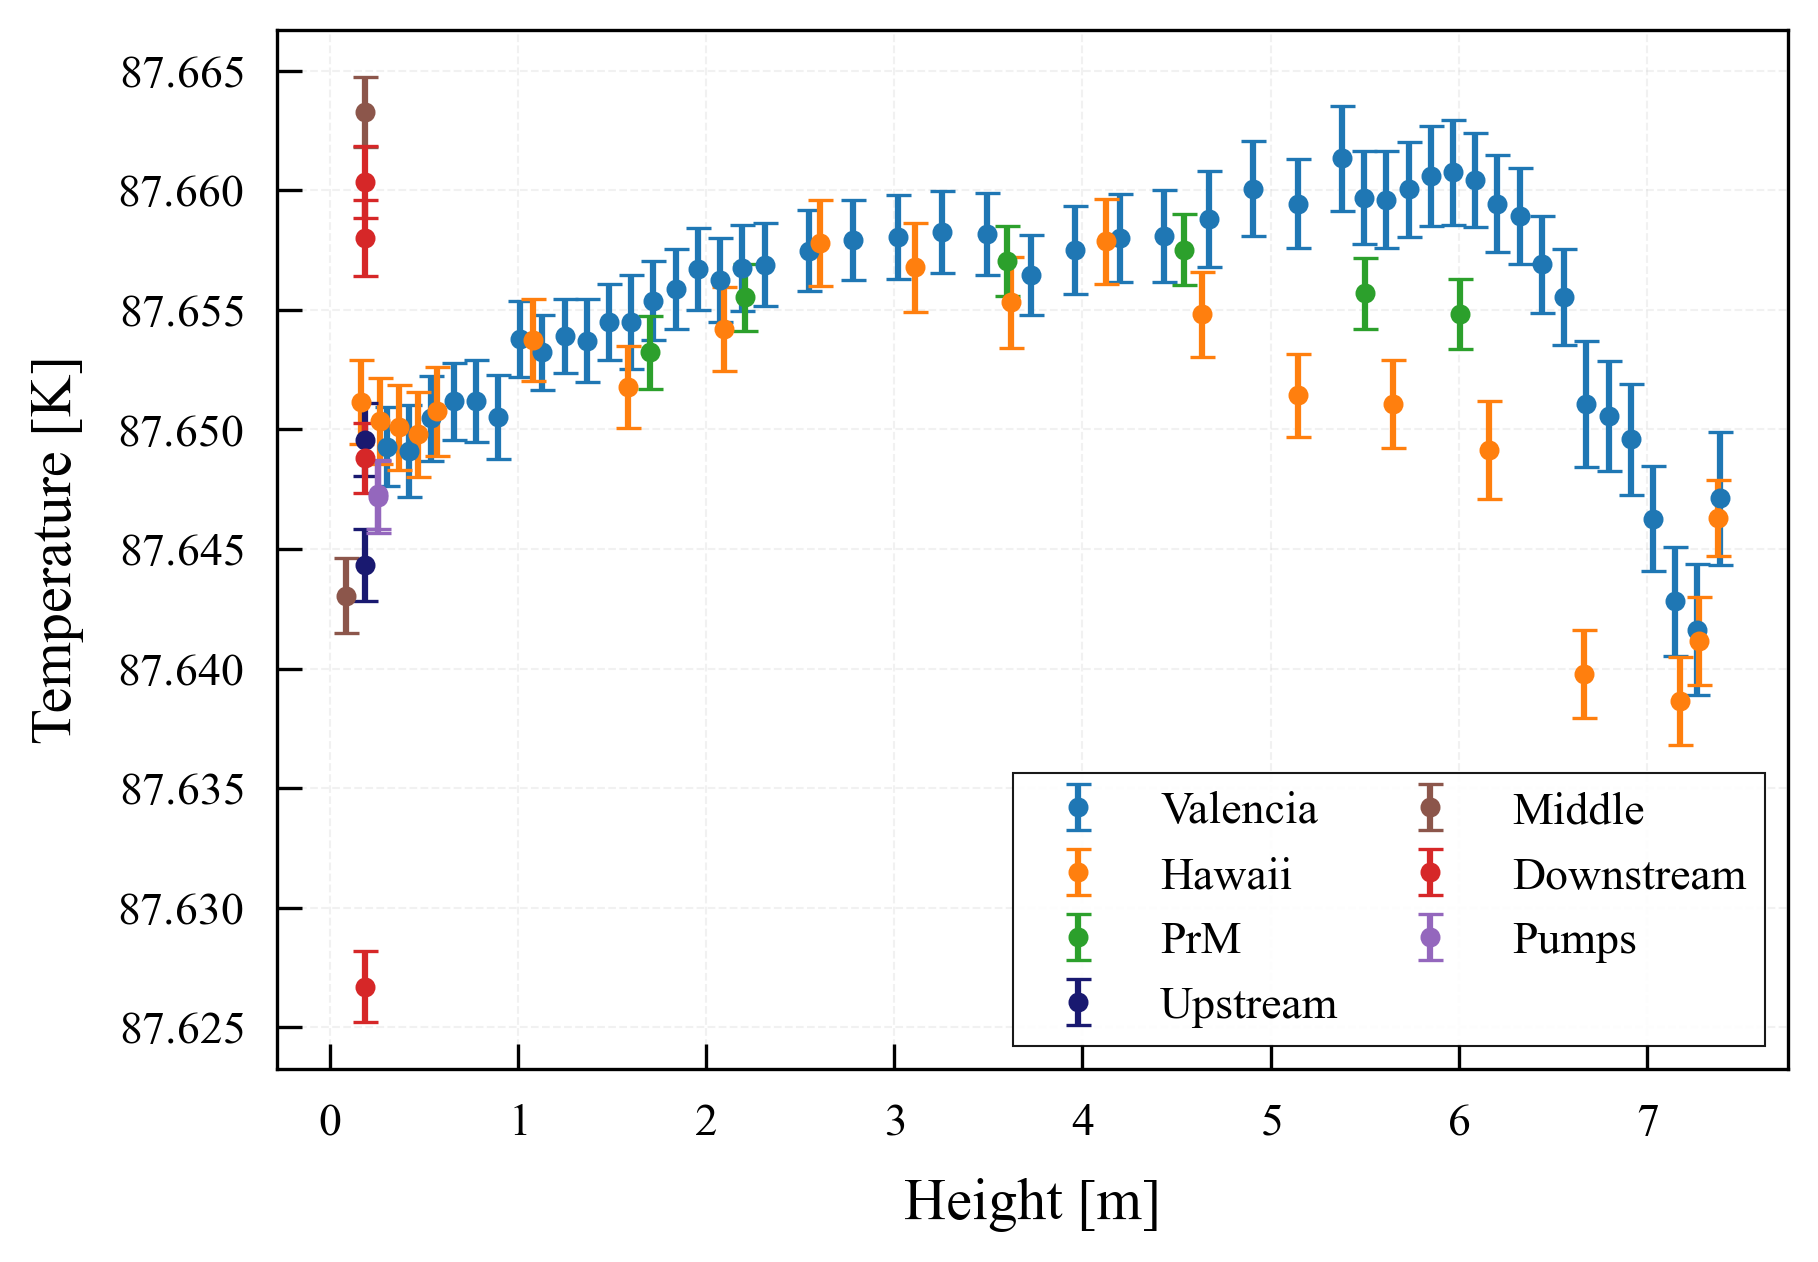

In [46]:
fig, axes = plt.subplots(1,1)
axes.errorbar(1e-3*tgrad_gaussian_first["Y"].values, 1e-3*tgrad_gaussian_first["mu"].values, yerr=1e-3*tgrad_gaussian_first["sigma"].values, fmt="o", label="Valencia", color="tab:blue")
axes.errorbar(1e-3*hawai_gaussian_first["Y"].values, 1e-3*hawai_gaussian_first["mu"].values, yerr=1e-3*hawai_gaussian_first["sigma"].values, fmt="o", label="Hawaii", color="tab:orange")
axes.errorbar(1e-3*prm_gaussian_first["Y"].values, 1e-3*prm_gaussian_first["mu"].values + corr_factor.mean(), yerr=1e-3*prm_gaussian_first["sigma"].values, fmt="o", label="PrM", color="tab:green")
# axes.errorbar(1e-3*pipes_gaussian_first["Y"].values, 1e-3*pipes_gaussian_first["mu"].values + corr_factor.mean(), yerr=1e-3*pipes_gaussian_first["sigma"].values, fmt="o", label="Pipes")
# axes.errorbar(1e-3*inlet_gaussian_first["Y"].values, 1e-3*inlet_gaussian_first["mu"].values + corr_factor.mean(), yerr=1e-3*inlet_gaussian_first["sigma"].values, fmt="o", label="Inlet")
axes.errorbar(1e-3*upstream_gaussian_first["Y"].values, 1e-3*upstream_gaussian_first["mu"].values + corr_factor.mean(), yerr=1e-3*upstream_gaussian_first["sigma"].values, fmt="o", label="Upstream", color="midnightblue")
axes.errorbar(1e-3*middle_gaussian_first["Y"].values, 1e-3*middle_gaussian_first["mu"].values + corr_factor.mean(), yerr=1e-3*middle_gaussian_first["sigma"].values, fmt="o", label="Middle", color="tab:brown")
axes.errorbar(1e-3*downstream_gaussian_first["Y"].values, 1e-3*downstream_gaussian_first["mu"].values + corr_factor.mean(), yerr=1e-3*downstream_gaussian_first["sigma"].values, fmt="o", label="Downstream", color="tab:red")
axes.errorbar(1e-3*pumps_gaussian_first["Y"].values, 1e-3*pumps_gaussian_first["mu"].values + corr_factor.mean(), yerr=1e-3*pumps_gaussian_first["sigma"].values, fmt="o", label="Pumps", color="tab:purple")
axes.set_xlabel("Height [m]")
axes.set_ylabel("Temperature [K]")
axes.legend(ncol=2)
fig.savefig("/Users/jcapo/cernbox/DUNE-IFIC/Publications/NP04_TMS/TMAPS/homogeneity_first.png")

# Second Normal Operation Period

Goal is to evaluate the homogeneity of the temperature map during the second normal operation period

In [4]:
dataset = baseClasses.Data()

In [5]:
mask = (
    ((dataset.data.index > datetime.datetime(2024, 10, 15)) & (dataset.data.index < datetime.datetime(2024, 11, 1))) |
    ((dataset.data.index > datetime.datetime(2024, 11, 8)) & (dataset.data.index < datetime.datetime(2024, 11, 29)))
)

dataset.data = dataset.data.loc[mask]
dataset.err = dataset.err.loc[mask]

In [6]:
tgrad = systemClasses.System(dataset, "TGRAD")
apa = systemClasses.System(dataset, "APA")
apa1 = systemClasses.System(dataset, sensor_names=["APA1LAr1", "APA1LAr4"])
apa2 = systemClasses.System(dataset, sensor_names=["APA2LAr1", "APA2LAr2", "APA2LAr3", "APA2LAr4"])
apa3 = systemClasses.System(dataset, sensor_names=["APA3LAr1", "APA3LAr2", "APA3LAr3", "APA3LAr4"])
apa4 = systemClasses.System(dataset, sensor_names=["APA4LAr1", "APA4LAr4"])
apa = systemClasses.System(dataset, name="APA")
pipes = systemClasses.System(dataset, "PIPE")
inlet = systemClasses.System(dataset, sensor_names=["1-I", "3-I", "4-I"])
upstream = systemClasses.System(dataset, sensor_names=["2-M", "4-M"])
middle = systemClasses.System(dataset, sensor_names=["1-M", "3-M"])
downstream = systemClasses.System(dataset, sensor_names=["1-U", "2-U", "3-U", "4-U"])
pumps = systemClasses.System(dataset, "PP")
prm = systemClasses.System(dataset, "PRM")
tgrad.calibrate("SECOND_POFF_OCTOBER")
apa.calibrate("SECOND_POFF_OCTOBER")
pipes.calibrate("SECOND_POFF_OCTOBER")
pumps.calibrate("SECOND_POFF_OCTOBER")
prm.calibrate("SECOND_POFF_OCTOBER")
apa1.calibrate("SECOND_POFF_OCTOBER")
apa2.calibrate("SECOND_POFF_OCTOBER")
apa3.calibrate("SECOND_POFF_OCTOBER")
apa4.calibrate("SECOND_POFF_OCTOBER")
inlet.calibrate("SECOND_POFF_OCTOBER")
upstream.calibrate("SECOND_POFF_OCTOBER")
middle.calibrate("SECOND_POFF_OCTOBER")
downstream.calibrate("SECOND_POFF_OCTOBER")

Initializing PIPE Sensors: 100%|██████████| 12/12 [00:00<00:00, 12.40sensor/s]


ERROR: Channel (TE0120) not found


Initializing Custom Sensors: 100%|██████████| 2/2 [00:00<00:00, 12.38sensor/s]


ERROR: Channel (TE0120) not found


Equalizing TGRAD Sensors: 100%|██████████| 48/48 [00:04<00:00, 11.42sensor/s]
Calibrating TGRAD Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 48/48 [00:00<00:00, 88.14sensor/s] 
Equalizing APA Sensors: 100%|██████████| 16/16 [00:01<00:00, 15.83sensor/s]
Calibrating APA Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 16/16 [00:00<00:00, 105.14sensor/s]
Equalizing PIPE Sensors: 100%|██████████| 12/12 [00:01<00:00, 10.92sensor/s]


ERROR: Channel (TE0120) not found


Calibrating PIPE Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 12/12 [00:00<00:00, 103.39sensor/s]
Equalizing PP Sensors: 100%|██████████| 2/2 [00:00<00:00, 11.91sensor/s]
Calibrating PP Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 2/2 [00:00<00:00, 97.73sensor/s]
Equalizing PRM Sensors: 100%|██████████| 6/6 [00:00<00:00, 10.60sensor/s]
Calibrating PRM Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 6/6 [00:00<00:00, 102.79sensor/s]
Equalizing Custom Sensors: 100%|██████████| 2/2 [00:00<00:00, 11.02sensor/s]
Calibrating Custom Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 2/2 [00:00<00:00, 92.49sensor/s]
Equalizing Custom Sensors: 100%|██████████| 4/4 [00:00<00:00, 19.73sensor/s]
Calibrating Custom Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 4/4 [00:00<00:00, 99.58sensor/s]
Equalizing Custom Sensors: 100%|██████████| 4/4 [00:00<00:00, 19.52sensor/s]
Calibrating Custom Sensors - Calibrat

ERROR: Channel (TE0120) not found


Calibrating Custom Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 2/2 [00:00<00:00, 91.08sensor/s]
Equalizing Custom Sensors: 100%|██████████| 2/2 [00:00<00:00, 10.91sensor/s]
Calibrating Custom Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 2/2 [00:00<00:00, 93.31sensor/s]
Equalizing Custom Sensors: 100%|██████████| 4/4 [00:00<00:00, 11.02sensor/s]
Calibrating Custom Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 4/4 [00:00<00:00, 100.79sensor/s]


In [7]:
tgrad.makeProfiles(deltat=45)
apa.makeProfiles(deltat=45)
prm.makeProfiles(deltat=45)
pipes.makeProfiles(deltat=45)
pumps.makeProfiles(deltat=45)
apa1.makeProfiles(deltat=45)
apa2.makeProfiles(deltat=45)
apa3.makeProfiles(deltat=45)
apa4.makeProfiles(deltat=45)
inlet.makeProfiles(deltat=45)
upstream.makeProfiles(deltat=45)
middle.makeProfiles(deltat=45)
downstream.makeProfiles(deltat=45)


Calculating TGRAD temperature profiles every 45 minutes: : 1440step [00:23, 62.07step/s]                      
Calculating APA temperature profiles every 45 minutes: : 1440step [00:07, 187.00step/s]                      
Calculating PRM temperature profiles every 45 minutes: : 1440step [00:03, 460.12step/s]                      
Calculating PIPE temperature profiles every 45 minutes: : 1440step [00:06, 231.70step/s]                      
Calculating PP temperature profiles every 45 minutes: : 1440step [00:01, 1120.05step/s]                      
Calculating Custom temperature profiles every 45 minutes: : 1440step [00:01, 1287.22step/s]                      
Calculating Custom temperature profiles every 45 minutes: : 1440step [00:02, 603.80step/s]                      
Calculating Custom temperature profiles every 45 minutes: : 1440step [00:02, 606.45step/s]                      
Calculating Custom temperature profiles every 45 minutes: : 1440step [00:01, 1250.60step/s]                 

In [8]:
tgrad_combined_second = combine_profiles(tgrad)
apa_combined_second = combine_profiles(apa)
prm_combined_second = combine_profiles(prm)
pipes_combined_second = combine_profiles(pipes)
pumps_combined_second = combine_profiles(pumps)
apa1_combined_second = combine_profiles(apa1)
apa2_combined_second = combine_profiles(apa2)
apa3_combined_second = combine_profiles(apa3)
apa4_combined_second = combine_profiles(apa4)
inlet_combined_second = combine_profiles(inlet)
upstream_combined_second = combine_profiles(upstream)
middle_combined_second = combine_profiles(middle)
downstream_combined_second = combine_profiles(downstream)

tgrad_gaussian_second = fit_gaussian_per_coord(tgrad_combined_second)
apa_gaussian_second = fit_gaussian_per_coord(apa_combined_second)
prm_gaussian_second = fit_gaussian_per_coord(prm_combined_second)
pipes_gaussian_second = fit_gaussian_per_coord(pipes_combined_second)
pumps_gaussian_second = fit_gaussian_per_coord(pumps_combined_second)
apa1_gaussian_second = fit_gaussian_per_coord(apa1_combined_second)
apa2_gaussian_second = fit_gaussian_per_coord(apa2_combined_second)
apa3_gaussian_second = fit_gaussian_per_coord(apa3_combined_second)
apa4_gaussian_second = fit_gaussian_per_coord(apa4_combined_second)
inlet_gaussian_second = fit_gaussian_per_coord(inlet_combined_second)
upstream_gaussian_second = fit_gaussian_per_coord(upstream_combined_second)
middle_gaussian_second = fit_gaussian_per_coord(middle_combined_second)
downstream_gaussian_second = fit_gaussian_per_coord(downstream_combined_second)

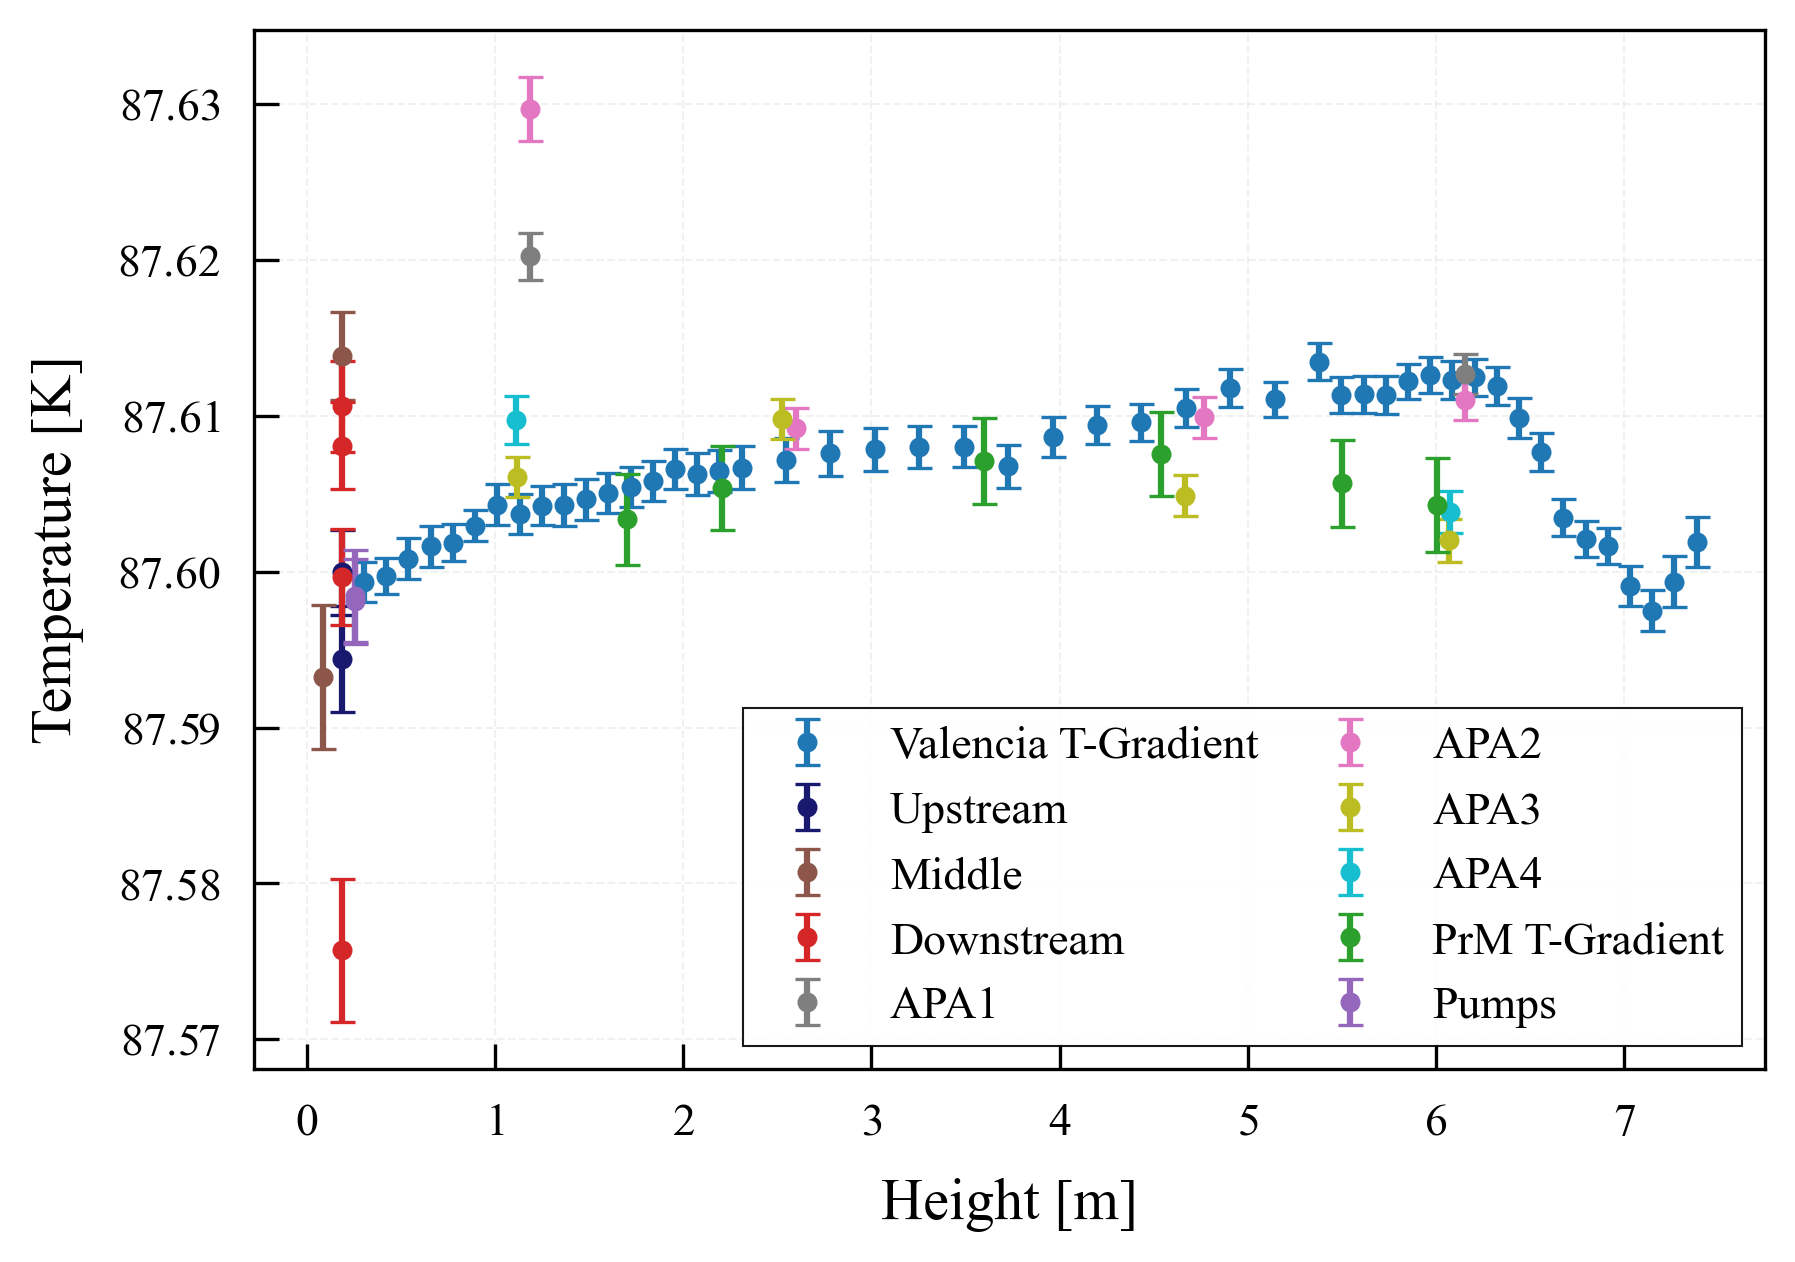

In [9]:
fig, axes = plt.subplots(1,1)
axes.errorbar(1e-3*tgrad_gaussian_second["Y"].values, 1e-3*tgrad_gaussian_second["mu"].values, yerr=1e-3*tgrad_gaussian_second["sigma"].values, fmt="o", label="Valencia T-Gradient", color="tab:blue")
axes.errorbar(1e-3*upstream_gaussian_second["Y"].values, 1e-3*upstream_gaussian_second["mu"].values, yerr=1e-3*upstream_gaussian_second["sigma"].values, fmt="o", label="Upstream", color="midnightblue")
axes.errorbar(1e-3*middle_gaussian_second["Y"].values, 1e-3*middle_gaussian_second["mu"].values, yerr=1e-3*middle_gaussian_second["sigma"].values, fmt="o", label="Middle", color="tab:brown")
axes.errorbar(1e-3*downstream_gaussian_second["Y"].values, 1e-3*downstream_gaussian_second["mu"].values, yerr=1e-3*downstream_gaussian_second["sigma"].values, fmt="o", label="Downstream", color="tab:red")
axes.errorbar(1e-3*apa1_gaussian_second["Y"].values, 1e-3*apa1_gaussian_second["mu"].values, yerr=1e-3*apa1_gaussian_second["sigma"].values, fmt="o", label="APA1", color="tab:gray")
axes.errorbar(1e-3*apa2_gaussian_second["Y"].values, 1e-3*apa2_gaussian_second["mu"].values, yerr=1e-3*apa2_gaussian_second["sigma"].values, fmt="o", label="APA2", color="tab:pink")
axes.errorbar(1e-3*apa3_gaussian_second["Y"].values, 1e-3*apa3_gaussian_second["mu"].values, yerr=1e-3*apa3_gaussian_second["sigma"].values, fmt="o", label="APA3", color="tab:olive")
axes.errorbar(1e-3*apa4_gaussian_second["Y"].values, 1e-3*apa4_gaussian_second["mu"].values, yerr=1e-3*apa4_gaussian_second["sigma"].values, fmt="o", label="APA4", color="tab:cyan")
axes.errorbar(1e-3*prm_gaussian_second["Y"].values, 1e-3*prm_gaussian_second["mu"].values, yerr=1e-3*prm_gaussian_second["sigma"].values, fmt="o", label="PrM T-Gradient", color="tab:green")
axes.errorbar(1e-3*pumps_gaussian_second["Y"].values, 1e-3*pumps_gaussian_second["mu"].values, yerr=1e-3*pumps_gaussian_second["sigma"].values, fmt="o", label="Pumps", color="tab:purple")
axes.set_xlabel("Height [m]")
axes.set_ylabel("Temperature [K]")
axes.legend(ncol=2)
fig.savefig("/Users/jcapo/cernbox/DUNE-IFIC/Publications/NP04_TMS/TMAPS/homogeneity_second.png")

/var/folders/2t/9f64gwx57z3375hyl7mpxd3h0000gn/T/ipykernel_8342/1931865158.py:68: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  cbar = plt.colorbar(scatter, ax=ax)


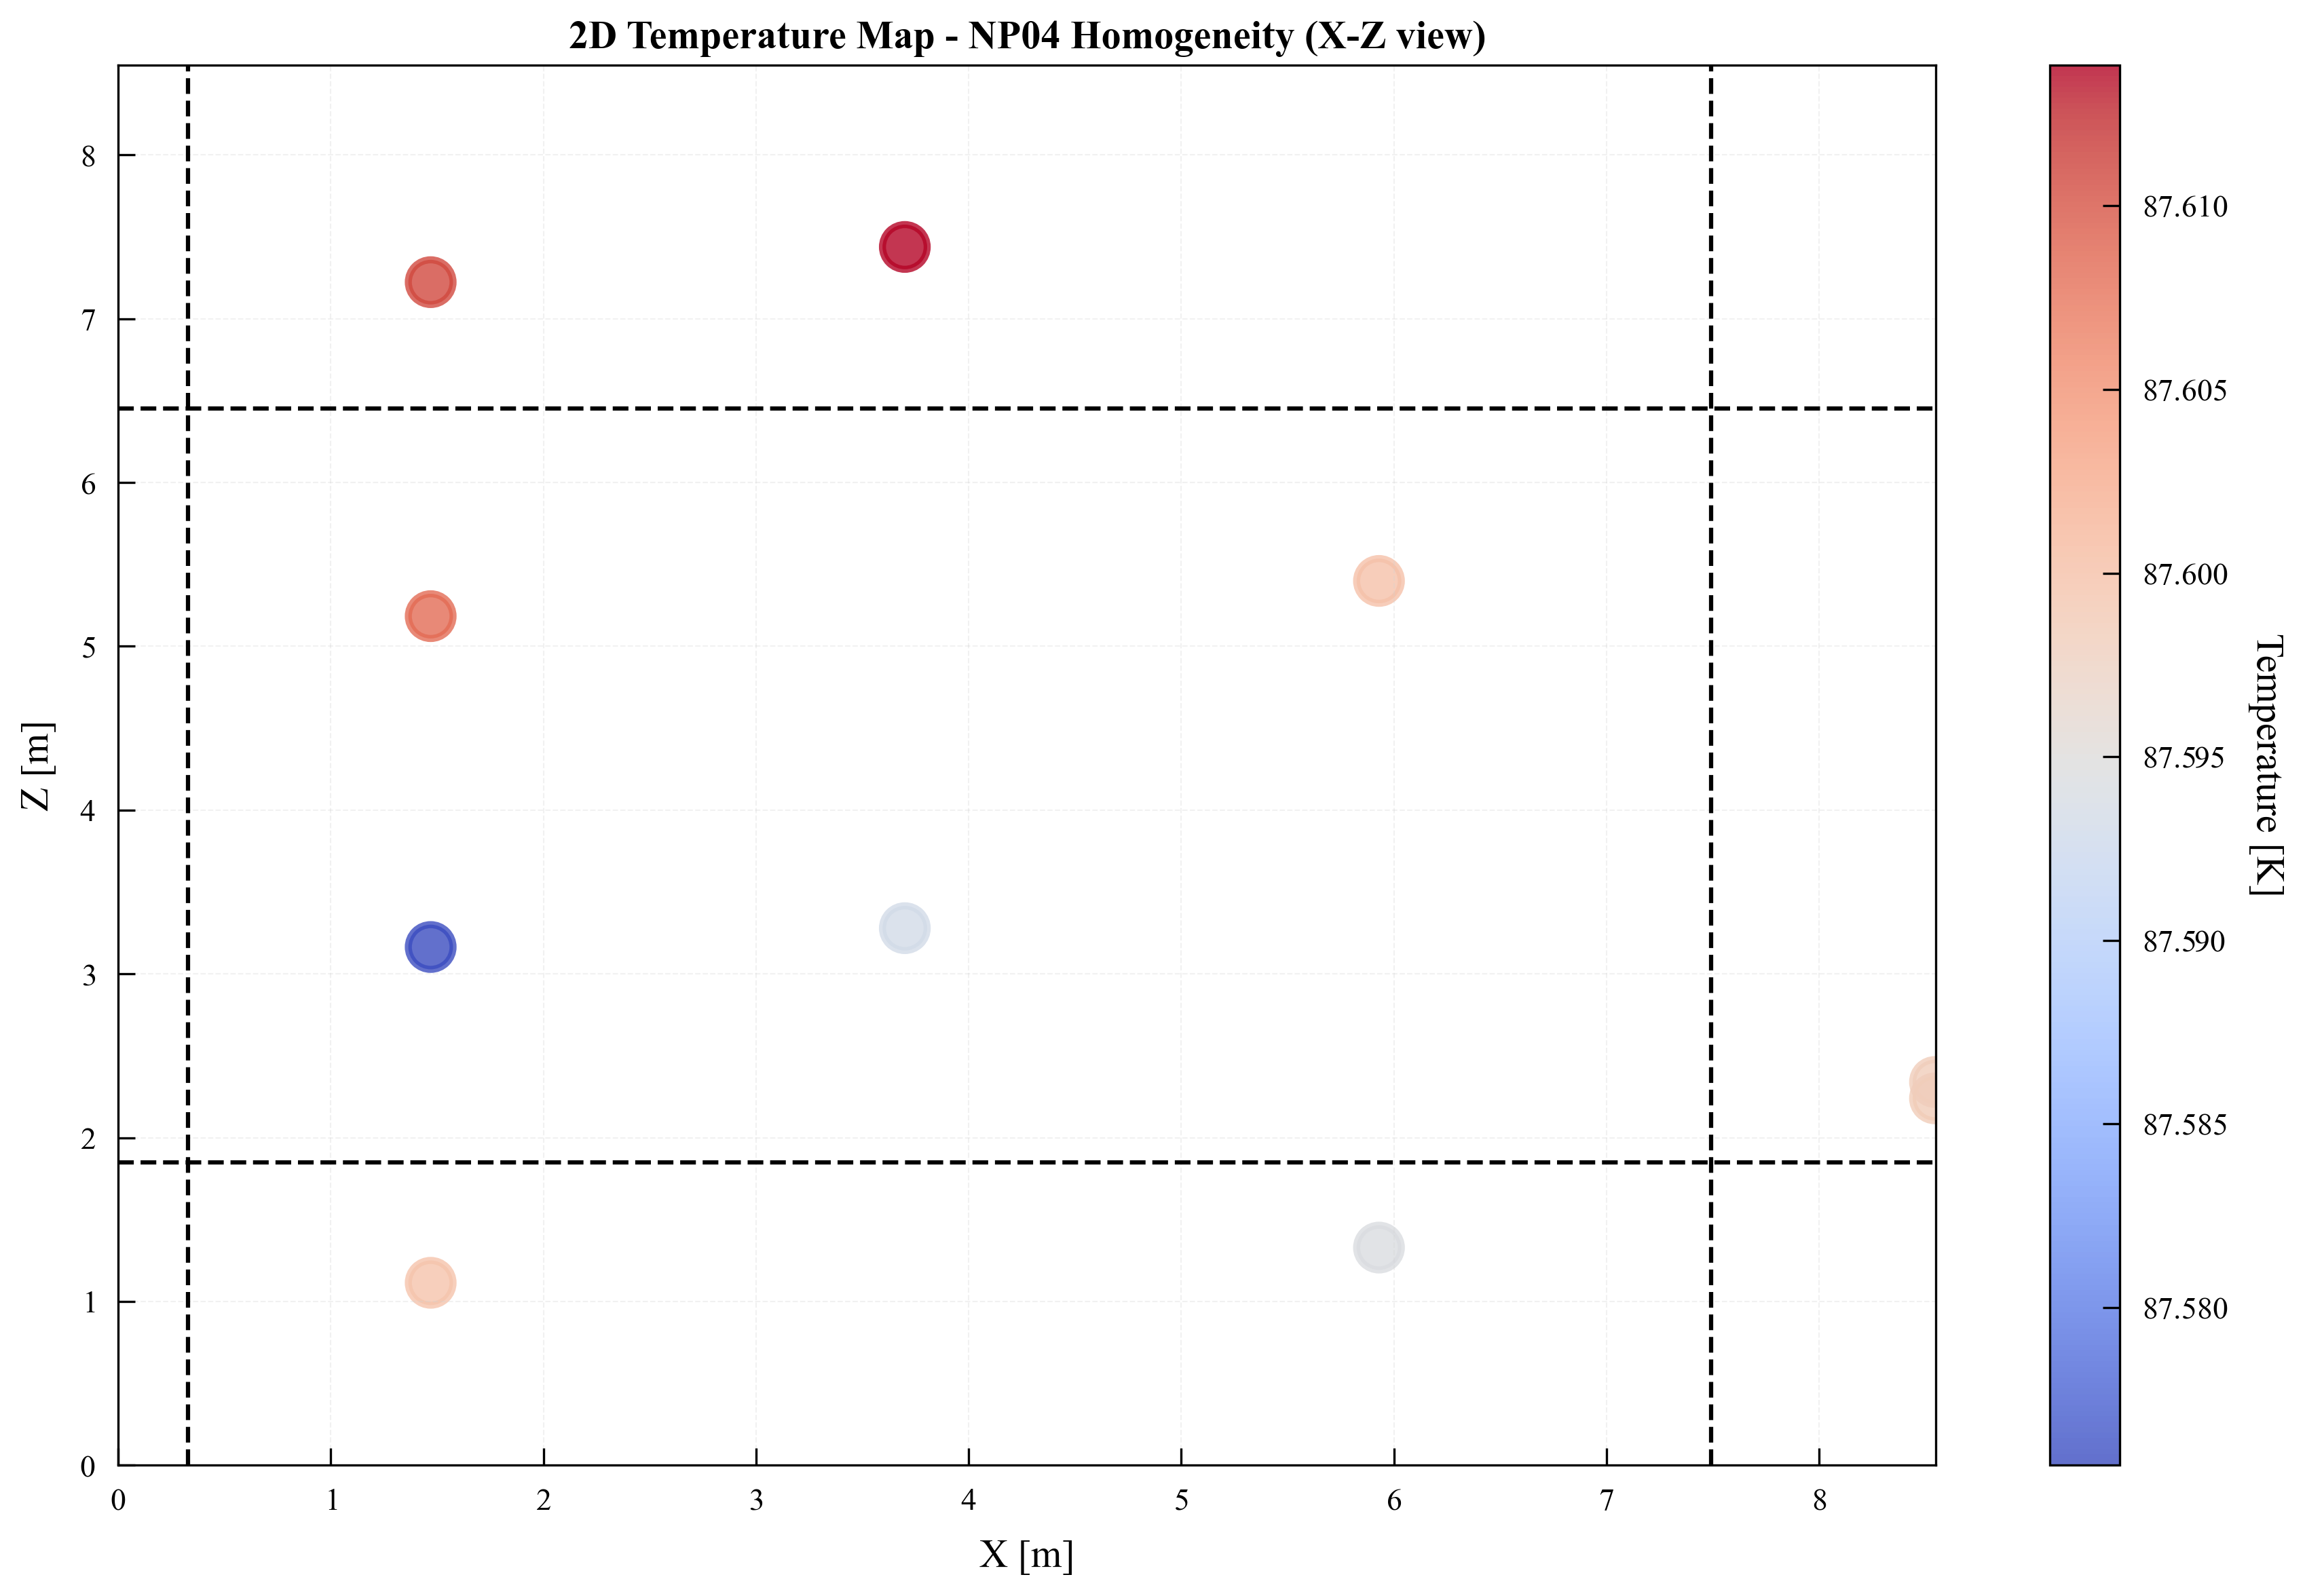

In [14]:
# Create 2D temperature map (X, Z coordinates with temperature as color)
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# Combine all datasets with their corresponding colors
datasets_2d = [
    (tgrad_gaussian_second, "Valencia T-Gradient", "tab:blue"),
    (upstream_gaussian_second, "Upstream", "midnightblue"),
    (middle_gaussian_second, "Middle", "tab:brown"),
    (downstream_gaussian_second, "Downstream", "tab:red"),
    (apa1_gaussian_second, "APA1", "tab:gray"),
    (apa2_gaussian_second, "APA2", "tab:pink"),
    (apa3_gaussian_second, "APA3", "tab:olive"),
    (apa4_gaussian_second, "APA4", "tab:cyan"),
    (prm_gaussian_second, "PrM T-Gradient", "tab:green"),
    (pumps_gaussian_second, "Pumps", "tab:purple")
]

# First, collect all points for unified colormap
all_x, all_z, all_y, all_temps = [], [], [], []
all_colors = []

for data, label, color in datasets_2d:
    x_coords = 1e-3 * data["X"].values
    y_coords = 1e-3 * data["Y"].values
    z_coords = 1e-3 * data["Z"].values if "Z" in data.columns else np.zeros(len(x_coords))
    temps = 1e-3 * data["mu"].values

    all_x.extend(x_coords)
    all_z.extend(z_coords)
    all_y.extend(y_coords)
    all_temps.extend(temps)
    all_colors.extend([color] * len(x_coords))

# Create unified scatter plot with proper colormap
all_x = np.array(all_x)
all_z = np.array(all_z)
all_y = np.array(all_y)
all_temps = np.array(all_temps)
all_colors = np.array(all_colors)

# Filter out points with temperature below 87.57 K
# mask = (all_temps >= 87.59) & (all_y < 0.3)
mask = (all_y < 0.3)
all_x = all_x[mask]
all_z = all_z[mask]
all_temps = all_temps[mask]
all_colors = all_colors[mask]

# Create the scatter plot with unified colormap
scatter = ax.scatter(all_x, all_z, c=all_temps,
                    cmap='coolwarm', s=250,
                    alpha=0.8, linewidth=2.5,
                    vmin=all_temps.min(), vmax=all_temps.max())

ax.axvline(x=0.33, color="black", linestyle="--")
ax.axvline(x=7.491, color="black", linestyle="--")
ax.axhline(y=1.85, color="black", linestyle="--")
ax.axhline(y=6.45, color="black", linestyle="--")
# Set labels
ax.set_xlabel('X [m]')
ax.set_ylabel('Z [m]')
ax.set_xlim(0,8.55)
ax.set_ylim(0,8.55)
ax.set_title('2D Temperature Map - NP04 Homogeneity (X-Z view)')
ax.grid(True, alpha=0.3)

# Add colorbar with proper range
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Temperature [K]', rotation=270, labelpad=20)

plt.tight_layout()
plt.show()
fig.savefig("/Users/jcapo/cernbox/DUNE-IFIC/Publications/NP04_TMS/TMAPS/homogeneity_pipes.png")


In [ ]:
#